In [6]:
import os
import numpy as np
from pathlib import Path
from tqdm import tqdm
from skimage.transform import resize

In [7]:
DATASET_DIR = Path("train")

GT_DIR = DATASET_DIR / "GT"
NOISYLR_DIR = DATASET_DIR / "NoisyLR"

OUTPUT_DIR = DATASET_DIR / "Preprocessed_Augmented"

GT_OUT = OUTPUT_DIR / "GT"
LR_OUT = OUTPUT_DIR / "NoisyLR"

GT_OUT.mkdir(parents=True, exist_ok=True)
LR_OUT.mkdir(parents=True, exist_ok=True)


In [8]:
GT_SIZE = (256, 256)
AUGMENTATIONS = 1
def load_npy(path):
    image = np.load(path)
    image = np.squeeze(image)
    if image.ndim == 3:

        if image.shape[0] in [1, 3]:
            image = np.transpose(
                image,
                (1, 2, 0)
            )

    return image
def normalize_image(image):
    image = image.astype(np.float32)
    if image.max() > 1.0:
        image = image / 255.0

    return np.clip(
        image,
        0.0,
        1.0
    )

def augment_pair(gt, lr, mode):

 
    if mode == 0:

        return gt, lr

 

    elif mode == 1:

        gt_aug = np.fliplr(gt)
        lr_aug = np.fliplr(lr)

    elif mode == 2:

        gt_aug = np.flipud(gt)
        lr_aug = np.flipud(lr)


    elif mode == 3:

        gt_aug = np.rot90(gt, k=1)
        lr_aug = np.rot90(lr, k=1)

 
    elif mode == 4:

        gt_aug = np.rot90(gt, k=2)
        lr_aug = np.rot90(lr, k=2)

    elif mode == 5:

        gt_aug = np.rot90(gt, k=3)
        lr_aug = np.rot90(lr, k=3)

    else:

        gt_aug = gt
        lr_aug = lr

    return (
        gt_aug.copy(),
        lr_aug.copy()
    )


In [9]:
gt_files = sorted( GT_DIR.glob("*.npy") )
total_saved = 0
for gt_path in tqdm( gt_files, desc="Processing"):
    image_name = gt_path.stem
    lr_path = (
        NOISYLR_DIR /
        f"{image_name}.npy"
    )
    if not lr_path.exists():
        print(
            f"\nMissing LR image: {image_name}"
        )
        continue
    try:
        gt = load_npy(gt_path)
        lr = load_npy(lr_path)
        gt = normalize_image(gt)
        lr = normalize_image(lr)
        for aug_id in range( AUGMENTATIONS + 1 ):
            gt_aug, lr_aug = augment_pair(
                gt,
                lr,
                aug_id
            )
            if aug_id == 0:

                suffix = "original"

            elif aug_id == 1:

                suffix = "hflip"

            elif aug_id == 2:

                suffix = "vflip"

            elif aug_id == 3:

                suffix = "rot90"

            elif aug_id == 4:

                suffix = "rot180"

            elif aug_id == 5:

                suffix = "rot270"

            np.save(
                GT_OUT /
                f"{image_name}_{suffix}.npy",
                gt_aug
            )

            np.save(
                LR_OUT /
                f"{image_name}_{suffix}.npy",
                lr_aug
            )

            total_saved += 1

    except Exception as e:
        print(e)
        



Processing: 100%|█████████████████████████████████████████████████████████████████| 3200/3200 [00:17<00:00, 180.23it/s]


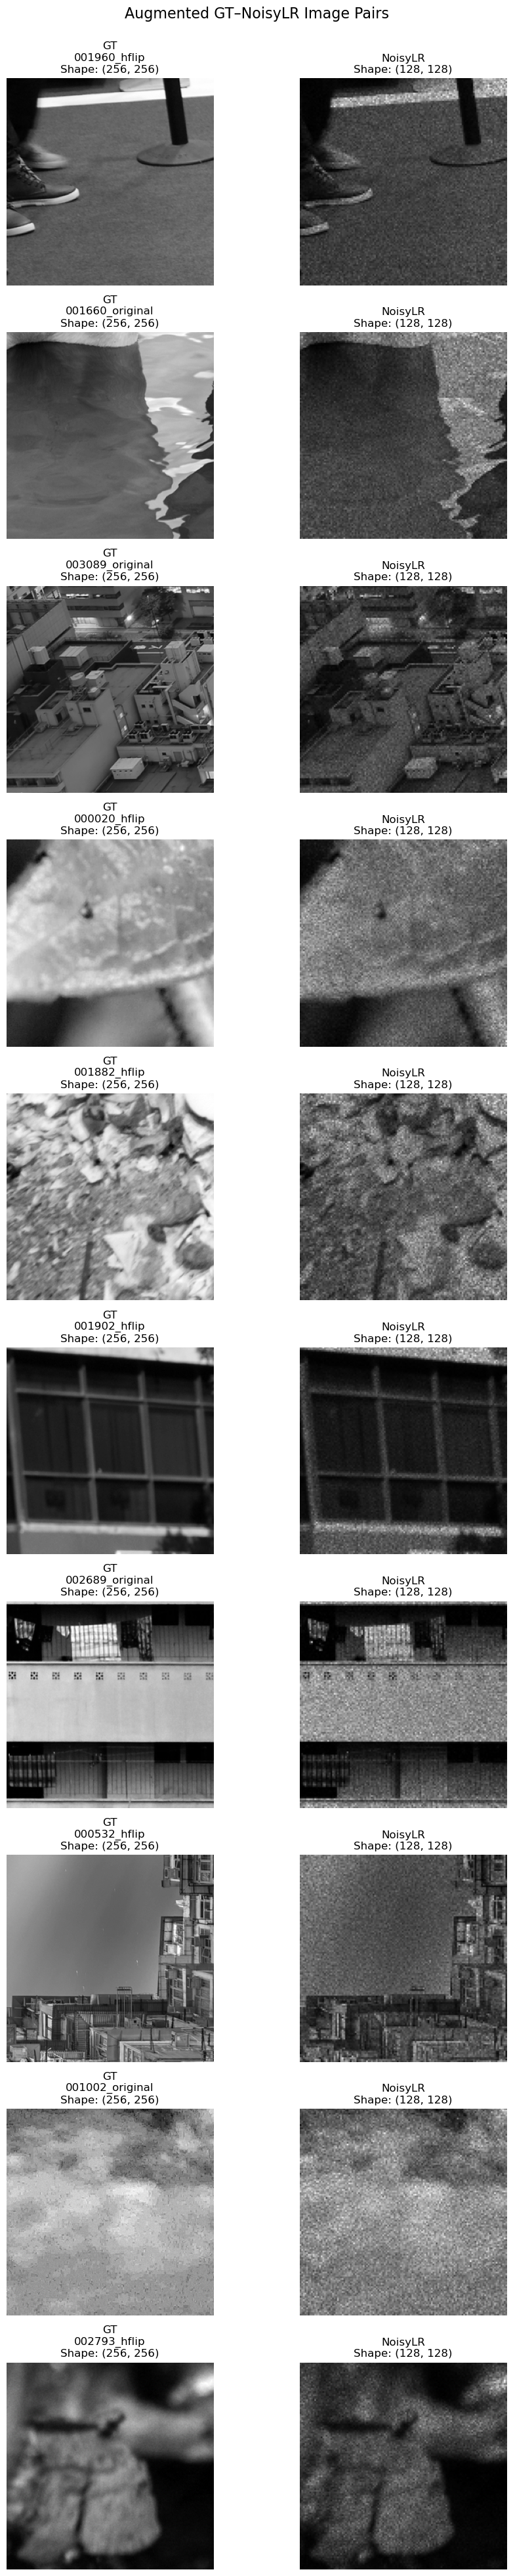

In [10]:
import random
import matplotlib.pyplot as plt
import numpy as np

augmented_gt_files = sorted(GT_OUT.glob("*.npy"))
num_samples = min(10, len(augmented_gt_files))
sample_gt_files = random.sample(augmented_gt_files, num_samples)

fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

def display_normalize(img):
    img = img.astype(np.float32)
    min_val = img.min()
    max_val = img.max()
    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    return np.clip(img, 0, 1)

for row, gt_path in enumerate(sample_gt_files):
    image_name = gt_path.stem
    lr_path = LR_OUT / f"{image_name}.npy"

    if not lr_path.exists():
        continue

    gt_img = np.load(gt_path)
    lr_img = np.load(lr_path)

    gt_display = display_normalize(gt_img)
    lr_display = display_normalize(lr_img)

    if gt_display.ndim == 2:
        axes[row, 0].imshow(gt_display, cmap="gray")
    else:
        axes[row, 0].imshow(gt_display)
    axes[row, 0].set_title(f"GT\n{image_name}\nShape: {gt_img.shape}")
    axes[row, 0].axis("off")

    if lr_display.ndim == 2:
        axes[row, 1].imshow(lr_display, cmap="gray")
    else:
        axes[row, 1].imshow(lr_display)
    axes[row, 1].set_title(f"NoisyLR\nShape: {lr_img.shape}")
    axes[row, 1].axis("off")

fig.suptitle("Augmented GT–NoisyLR Image Pairs", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()